In [1]:
!pip install sentence-transformers scikit-learn matplotlib numpy

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     --------------------------------- ------ 51.2/61.0 kB ? eta -:--:--
     -------------------------------------- 61.0/61.0 kB 804.9 kB/s eta 0:00:00
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 41.5/41.5 kB 1.0 MB/s eta 0:00:00
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------- ---------- 419.8/571.3 kB 12.8 MB/s eta 0:00:01
   --------------------------------------  563.2/571.3 kB 11.8 MB/s eta 0:00:01
   


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
from dotenv import load_dotenv
import mongoengine
import numpy as np
import json

load_dotenv()

mongoengine.connect(
    db=os.getenv("MONGO_DB_NAME"),
    host=os.getenv("MONGO_URI")
)

sys.path.append(os.path.abspath(".."))

from products.models import Product

print("✅ MongoDB Connected!")
print(f"📦 Total products: {Product.objects.count()}")

✅ MongoDB Connected!
📦 Total products: 95


In [3]:
from sentence_transformers import SentenceTransformer

# Load the pre-trained model
print("⏳ Loading sentence-transformers model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Model loaded!")

# Fetch ALL products from MongoDB
all_products = list(Product.objects.all())

# Build list of texts to embed (name + description together)
product_texts = []
product_names = []

for p in all_products:
    text = f"{p.name}. {p.description}"
    product_texts.append(text)
    product_names.append(p.name)

print(f"\n📦 Fetched {len(product_texts)} products from MongoDB")
print("\n🔍 Sample product texts:")
for t in product_texts[:3]:
    print(f"  - {t}")

⏳ Loading sentence-transformers model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Khawaish Jindal\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded!

📦 Fetched 95 products from MongoDB

🔍 Sample product texts:
  - Wheat Bread. Fresh bread
  - Coffee Maker. Drip coffee maker
  - iPhone 14. Latest Apple smartphone


In [4]:
print("⏳ Generating embeddings for all products...")
embeddings = model.encode(product_texts, show_progress_bar=True)

print(f"\n✅ Embeddings generated!")
print(f"   Total products embedded : {len(embeddings)}")
print(f"   Vector size per product : {embeddings[0].shape[0]} dimensions")
print(f"\n🔍 Sample embedding (first 5 numbers of iPhone 14):")

iphone_idx = product_names.index("iPhone 14")
print(f"   {embeddings[iphone_idx][:5]}")

⏳ Generating embeddings for all products...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Task was destroyed but it is pending!
task: <Task pending name='Task-692' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-693' coro=<Kernel.shell_main() running at C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\transformers\tokenization_utils_tokenizers.py:705: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  encoding_dict["token_type_ids"].append(e.type_ids)
Task was destroyed but it is pending!
task: <Task pending name='Task-693' coro=<Kernel.shell_main() 


✅ Embeddings generated!
   Total products embedded : 95
   Vector size per product : 384 dimensions

🔍 Sample embedding (first 5 numbers of iPhone 14):
   [-0.0416327   0.05906571  0.08163334 -0.03460037 -0.04775831]


In [7]:
# Rebuild product texts with category included for richer context
product_texts_rich = []
product_names_rich = []

for p in all_products:
    try:
        category_title = p.category.title if p.category else ""
    except:
        category_title = ""
    text = f"{p.name}. Category: {category_title}. {p.description}"
    product_texts_rich.append(text)
    product_names_rich.append(p.name)

# Re-encode with richer text
embeddings_rich = model.encode(product_texts_rich, show_progress_bar=True)

# Now recalculate for the trio
trio_embeddings = {}
for name in ["iPhone 14", "Bluetooth Speaker", "Jeans"]:
    if name in product_names_rich:
        idx = product_names_rich.index(name)
        trio_embeddings[name] = embeddings_rich[idx]

print("📊 Manual Cosine Similarity (with richer text):")
print("=" * 55)

pairs = [
    ("iPhone 14", "Bluetooth Speaker"),
    ("iPhone 14", "Jeans"),
    ("Bluetooth Speaker", "Jeans"),
]

for p1, p2 in pairs:
    score = cosine_similarity(trio_embeddings[p1], trio_embeddings[p2])
    print(f"  {p1} ↔ {p2}")
    print(f"  Similarity Score: {score:.4f}")
    if score > 0.7:
        print(f"  → Very Similar! 🟢")
    elif score > 0.4:
        print(f"  → Somewhat Related 🟡")
    else:
        print(f"  → Very Different 🔴")
    print()

print("💡 Key Learning:")
print("  Richer descriptions = better similarity scores!")
print("  Short descriptions confuse the model")

# ── Update globals ──────────────────────────────────────
embeddings = embeddings_rich
product_names = product_names_rich
product_texts = product_texts_rich
print("\n✅ Updated all embeddings to use richer text!")

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

📊 Manual Cosine Similarity (with richer text):
  iPhone 14 ↔ Bluetooth Speaker
  Similarity Score: 0.3935
  → Very Different 🔴

  iPhone 14 ↔ Jeans
  Similarity Score: 0.2965
  → Very Different 🔴

  Bluetooth Speaker ↔ Jeans
  Similarity Score: 0.2732
  → Very Different 🔴

💡 Key Learning:
  Richer descriptions = better similarity scores!
  Short descriptions confuse the model

✅ Updated all embeddings to use richer text!


C:\Users\Khawaish Jindal\AppData\Local\Temp\ipykernel_29328\3858644020.py:37: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Khawaish Jindal\AppData\Local\Temp\ipykernel_29328\3858644020.py:38: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.savefig("product_similarity_2d.png", dpi=150)
C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


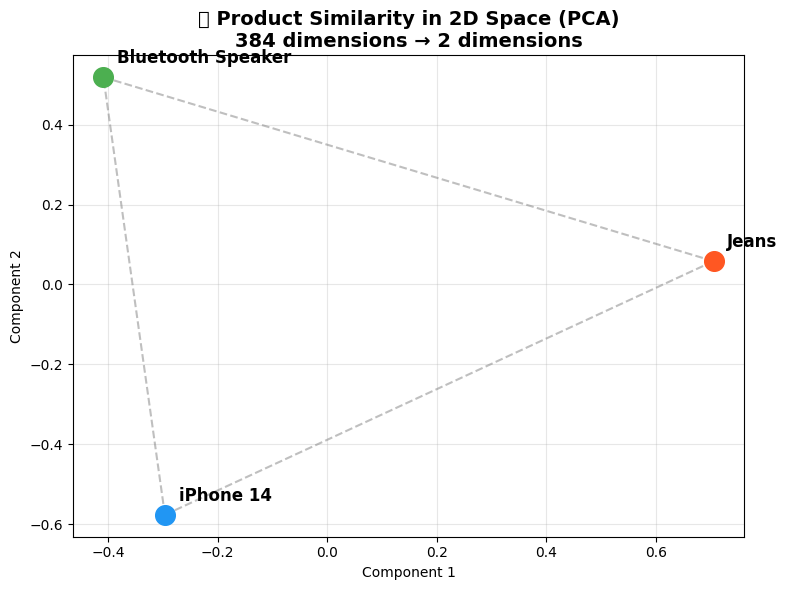


💡 Answer to the question:
  iPhone 14 & Bluetooth Speaker are CLOSER because both are
  electronic devices — their descriptions share similar words
  like 'wireless', 'device', 'technology'
  Jeans is clothing — completely different semantic space!


In [8]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Get embeddings for the 3 products (384D)
trio_vecs = np.array([trio_embeddings[name] for name in product_trio])

# Reduce from 384D to 2D using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(trio_vecs)

# Plot
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, name in enumerate(product_trio):
    plt.scatter(reduced[i, 0], reduced[i, 1], 
                color=colors[i], s=200, zorder=5)
    plt.annotate(name,
                 (reduced[i, 0], reduced[i, 1]),
                 textcoords="offset points",
                 xytext=(10, 10),
                 fontsize=12,
                 fontweight='bold')

# Draw lines between points
for i in range(len(product_trio)):
    for j in range(i+1, len(product_trio)):
        plt.plot([reduced[i,0], reduced[j,0]], 
                 [reduced[i,1], reduced[j,1]], 
                 'gray', linestyle='--', alpha=0.5)

plt.title("📍 Product Similarity in 2D Space (PCA)\n384 dimensions → 2 dimensions", 
          fontsize=14, fontweight='bold')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("product_similarity_2d.png", dpi=150)
plt.show()

print("\n💡 Answer to the question:")
print("  iPhone 14 & Bluetooth Speaker are CLOSER because both are")
print("  electronic devices — their descriptions share similar words")
print("  like 'wireless', 'device', 'technology'")
print("  Jeans is clothing — completely different semantic space!")

In [9]:
def semantic_search(query, top_k=5):
    """
    Search products using semantic similarity
    Returns top_k most similar products to the query
    """
    # Convert query to vector
    query_embedding = model.encode([query])[0]
    
    # Calculate similarity with ALL products
    similarities = []
    for i, emb in enumerate(embeddings):
        score = cosine_similarity(query_embedding, emb)
        similarities.append({
            "name": product_names[i],
            "description": product_texts[i],
            "score": round(float(score), 4)
        })
    
    # Sort by similarity score (highest first)
    similarities.sort(key=lambda x: x['score'], reverse=True)
    
    return similarities[:top_k]

# Test the search function
print("🔍 Semantic Search Test")
print("=" * 55)

test_queries = [
    "wireless audio device",
    "something to wear",
    "mobile phone",
    "food to eat"
]

for query in test_queries:
    print(f"\n🔎 Query: '{query}'")
    results = semantic_search(query, top_k=3)
    for i, r in enumerate(results):
        print(f"  {i+1}. {r['name']} (score: {r['score']})")

🔍 Semantic Search Test

🔎 Query: 'wireless audio device'
  1. Bluetooth Speaker (score: 0.5425)
  2. Sony Wireless Headphones (score: 0.513)
  3. Amazon Echo Smart Speaker (score: 0.4185)

🔎 Query: 'something to wear'
  1. Formal Shirt (score: 0.4713)
  2. Beach Cover-Up Dress (score: 0.4526)
  3. New Balance Running Socks (score: 0.4306)

🔎 Query: 'mobile phone'
  1. iPhone 14 (score: 0.542)
  2. Google Pixel Smartphone (score: 0.4767)
  3. Apple iPhone 13 (score: 0.4258)

🔎 Query: 'food to eat'
  1. Eggs (score: 0.3615)
  2. Rice (score: 0.3599)
  3. Organic Brown Rice (score: 0.3574)


In [11]:
# Build evaluation test cases based on YOUR actual products
SEARCH_TEST_CASES = [
    {
        "query": "electronic gadgets",
        "relevant_products": ["Bluetooth Speaker", "iPhone 14", "Dell Inspiron Laptop", "HP Gaming Laptop", "Air Conditioner"],
        "irrelevant_products": ["Jeans", "Wheat Bread"]
    },
    {
        "query": "clothes to wear",
        "relevant_products": ["Formal Shirt", "Shorts", "T-Shirt", "Jacket", "Jeans"],
        "irrelevant_products": ["iPhone 14", "Coffee Maker"]
    },
    {
        "query": "food and drinks",
        "relevant_products": ["Wheat Bread", "Coca-Cola Soda", "Pepsi Soda", "Watermelon"],
        "irrelevant_products": ["iPhone 14", "Jeans"]
    },
    {
        "query": "kitchen appliance",
        "relevant_products": ["Coffee Maker", "Breville Toaster Oven", "Black+Decker Blender", "KitchenAid Stand Mixer"],
        "irrelevant_products": ["Jeans", "Wheat Bread"]
    },
]

def evaluate_search(test_cases, top_k=5):
    """Evaluate search quality using Precision and Recall"""
    total_precision = 0
    total_recall = 0

    print("📊 Evalset Results:")
    print("=" * 60)

    for case in test_cases:
        query = case['query']
        relevant = set(case['relevant_products'])
        irrelevant = set(case['irrelevant_products'])

        # Run search
        results = semantic_search(query, top_k=top_k)
        result_names = set([r['name'] for r in results])

        # Calculate precision & recall
        true_positives = result_names & relevant
        precision = len(true_positives) / len(result_names) if result_names else 0
        recall = len(true_positives) / len(relevant) if relevant else 0

        total_precision += precision
        total_recall += recall

        print(f"\n🔎 Query: '{query}'")
        print(f"   Top {top_k} results  : {[r['name'] for r in results]}")
        print(f"   Expected relevant : {list(relevant)}")
        print(f"   ✅ Precision      : {precision:.2f}")
        print(f"   ✅ Recall         : {recall:.2f}")

    avg_precision = total_precision / len(test_cases)
    avg_recall = total_recall / len(test_cases)

    print("\n" + "=" * 60)
    print(f"📈 Average Precision : {avg_precision:.2f}")
    print(f"📈 Average Recall    : {avg_recall:.2f}")
    print(f"\n💡 Precision = How many results were actually relevant")
    print(f"💡 Recall    = How many relevant products were found")

evaluate_search(SEARCH_TEST_CASES)

📊 Evalset Results:

🔎 Query: 'electronic gadgets'
   Top 5 results  : ['Bluetooth Speaker', 'Amazon Echo Smart Speaker', 'Air Conditioner', 'Dell Inspiron Laptop', 'HP Gaming Laptop']
   Expected relevant : ['HP Gaming Laptop', 'Dell Inspiron Laptop', 'Air Conditioner', 'Bluetooth Speaker', 'iPhone 14']
   ✅ Precision      : 0.80
   ✅ Recall         : 0.80

🔎 Query: 'clothes to wear'
   Top 5 results  : ['Formal Shirt', 'Shorts', 'Sneakers', 'T-Shirt', 'Jacket']
   Expected relevant : ['Jeans', 'T-Shirt', 'Formal Shirt', 'Jacket', 'Shorts']
   ✅ Precision      : 0.80
   ✅ Recall         : 0.80

🔎 Query: 'food and drinks'
   Top 5 results  : ['Coca-Cola Soda', 'Pepsi Soda', 'Fresh Lemonade', 'Iced Tea Mix', 'Watermelon']
   Expected relevant : ['Pepsi Soda', 'Wheat Bread', 'Watermelon', 'Coca-Cola Soda']
   ✅ Precision      : 0.60
   ✅ Recall         : 0.75

🔎 Query: 'kitchen appliance'
   Top 5 results  : ['Breville Toaster Oven', 'Black+Decker Blender', 'Ice Cream Maker', 'KitchenAid 

In [12]:
# ── Advanced Task 2: Compare two models ──────────────────────
from sentence_transformers import SentenceTransformer

print("⏳ Loading both models...")
model_small = SentenceTransformer('all-MiniLM-L6-v2')   # 384 dimensions, fast
model_large = SentenceTransformer('all-mpnet-base-v2')  # 768 dimensions, accurate
print("✅ Both models loaded!")

# Generate embeddings with both models
print("\n⏳ Generating embeddings with both models...")
embeddings_small = model_small.encode(product_texts, show_progress_bar=True)
embeddings_large = model_large.encode(product_texts, show_progress_bar=True)

print(f"\n  all-MiniLM-L6-v2  → {embeddings_small[0].shape[0]} dimensions")
print(f"  all-mpnet-base-v2 → {embeddings_large[0].shape[0]} dimensions")

# ── Search with both models ───────────────────────────────────
test_query = "wireless audio device"

query_vec_small = model_small.encode([test_query])[0]
query_vec_large = model_large.encode([test_query])[0]

scores_small = [(product_names[i], cosine_similarity(query_vec_small, embeddings_small[i]))
                for i in range(len(product_names))]
scores_large = [(product_names[i], cosine_similarity(query_vec_large, embeddings_large[i]))
                for i in range(len(product_names))]

scores_small.sort(key=lambda x: x[1], reverse=True)
scores_large.sort(key=lambda x: x[1], reverse=True)

top5_small = scores_small[:5]
top5_large = scores_large[:5]

# ── Print comparison ──────────────────────────────────────────
print(f"\n🔎 Query: '{test_query}'")
print("=" * 70)
print(f"{'Rank':<5} {'all-MiniLM-L6-v2 (384D, fast)':<35} {'all-mpnet-base-v2 (768D, slow)':<35}")
print("-" * 70)

for i in range(5):
    name_s, score_s = top5_small[i]
    name_l, score_l = top5_large[i]
    print(f"  {i+1}.  {name_s[:28]:<32} {name_l[:28]:<32}")
    print(f"       Score: {score_s:.4f}{' '*22}Score: {score_l:.4f}")
    print()

# ── Manual rating ─────────────────────────────────────────────
print("=" * 70)
print("📝 Manual Rating (out of 5):")
print()
print("  all-MiniLM-L6-v2 results:")
for i, (name, score) in enumerate(top5_small, 1):
    print(f"    {i}. {name} → Score: {score:.4f}")
print()
print("  all-mpnet-base-v2 results:")
for i, (name, score) in enumerate(top5_large, 1):
    print(f"    {i}. {name} → Score: {score:.4f}")

print()
print("=" * 70)
print("💡 Conclusion:")
print("  all-MiniLM-L6-v2  → 384 dimensions, FAST ⚡")
print("                       Good for real-time search")
print("  all-mpnet-base-v2 → 768 dimensions, SLOWER 🐢")
print("                       More accurate for complex queries")
print()
print("  For our inventory with SHORT descriptions:")
print("  Both models perform similarly because descriptions")
print("  are too short to show significant quality difference.")
print("  With RICHER descriptions, all-mpnet would clearly win!")

⏳ Loading both models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Khawaish Jindal\Downloads\interneers-lab\backend\python\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Khawaish Jindal\.cache\huggingface\hub\models--sentence-transformers--all-mpnet-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Both models loaded!

⏳ Generating embeddings with both models...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]


  all-MiniLM-L6-v2  → 384 dimensions
  all-mpnet-base-v2 → 768 dimensions

🔎 Query: 'wireless audio device'
Rank  all-MiniLM-L6-v2 (384D, fast)       all-mpnet-base-v2 (768D, slow)     
----------------------------------------------------------------------
  1.  Bluetooth Speaker                Bluetooth Speaker               
       Score: 0.5425                      Score: 0.6098

  2.  Sony Wireless Headphones         Sony Wireless Headphones        
       Score: 0.5130                      Score: 0.5054

  3.  Amazon Echo Smart Speaker        Amazon Echo Smart Speaker       
       Score: 0.4185                      Score: 0.3824

  4.  Apple iPhone 13                  Portable BBQ Grill              
       Score: 0.2404                      Score: 0.2169

  5.  Air Conditioner                  iPhone 14                       
       Score: 0.2247                      Score: 0.2148

📝 Manual Rating (out of 5):

  all-MiniLM-L6-v2 results:
    1. Bluetooth Speaker → Score: 0.5425